Título: 02_pass_maps
Objetivo: “Cargar eventos procesados y generar mapas de pases con mplsoccer (por partido, por equipo y por jugador).”

1) Imports + rutas

In [4]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch


In [5]:
# Rutas robustas
PROJECT_ROOT = Path.cwd().parent  # notebooks/ -> root
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "events.parquet"

assert DATA_PATH.exists(), f"No existe: {DATA_PATH}"

df = pd.read_parquet(DATA_PATH)
df.shape


(187858, 48)

2) Sanity check

In [6]:
df["type"].value_counts().head(10)


type
Pass             53890
Ball Receipt*    51618
Carry            44139
Pressure         14544
Ball Recovery     4130
Duel              3059
Block             1992
Clearance         1852
Goal Keeper       1618
Shot              1340
Name: count, dtype: int64

In [7]:
# columnas clave que necesitamos para pases
cols_needed = ["match_id", "team", "player", "type", "x", "y", "end_x", "end_y", "pass_outcome"]
[c for c in cols_needed if c not in df.columns]


[]

3) Filtrar pases

In [8]:
passes = df[df["type"] == "Pass"].copy()

# completados (StatsBomb: outcome vacío = completado)
passes["is_completed"] = passes["pass_outcome"].isna()

passes.shape, passes["is_completed"].mean()


((53890, 49), np.float64(0.8420486175542772))

4) Elegir un partido

In [9]:
passes["match_id"].nunique(), passes["match_id"].value_counts().head()


(51,
 match_id
 3942349    1552
 3942227    1411
 3941017    1386
 3930161    1261
 3942226    1261
 Name: count, dtype: int64)

In [10]:
match_id = int(passes["match_id"].value_counts().index[0])
match_id


3942349

In [11]:
p_match = passes[passes["match_id"] == match_id].copy()
p_match.shape


(1552, 49)

5) Elegir un equipo

In [12]:
p_match["team"].value_counts()


team
Portugal    927
France      625
Name: count, dtype: int64

In [13]:
team_name = p_match["team"].value_counts().index[0]
team_name


'Portugal'

In [14]:
p_team = p_match[p_match["team"] == team_name].copy()
p_team.shape


(927, 49)

6) Primer mapa de pases (todos)

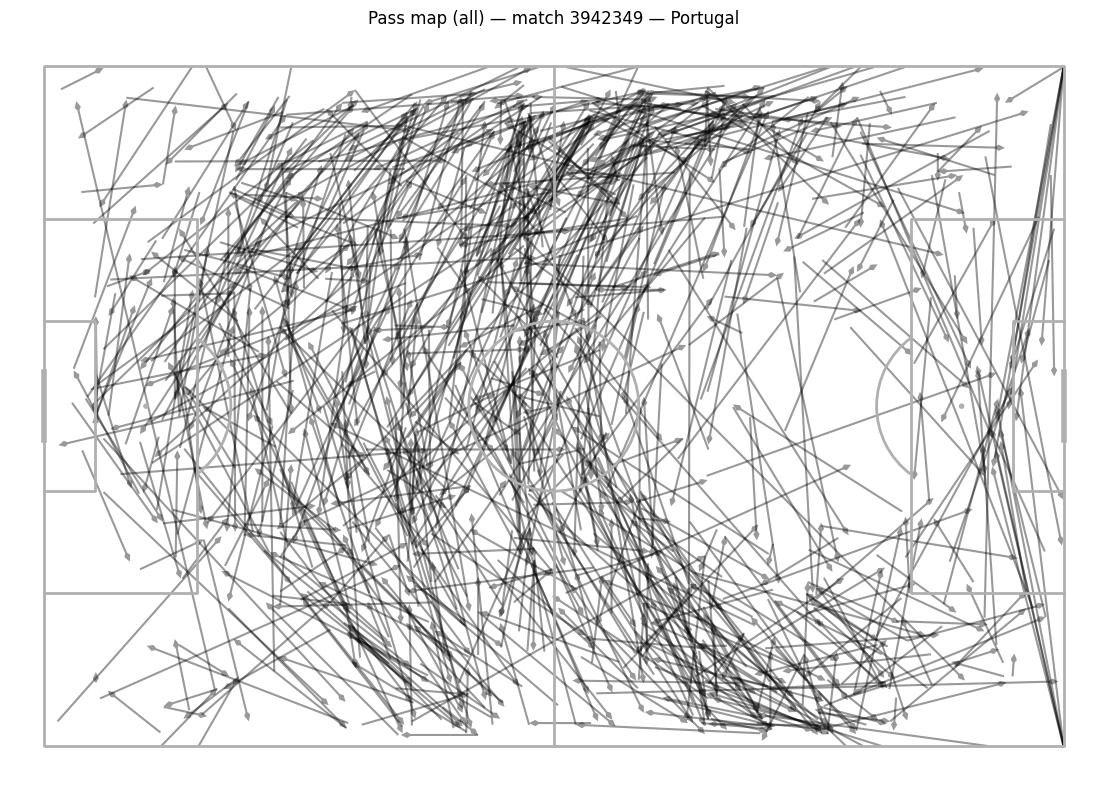

In [15]:
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

# todos los pases
pitch.arrows(
    p_team["x"], p_team["y"],
    p_team["end_x"], p_team["end_y"],
    ax=ax,
    width=1.5,
    headwidth=3,
    headlength=3,
    alpha=0.4
)

ax.set_title(f"Pass map (all) — match {match_id} — {team_name}")
plt.show()


7) Mapa de pases completados vs no completados

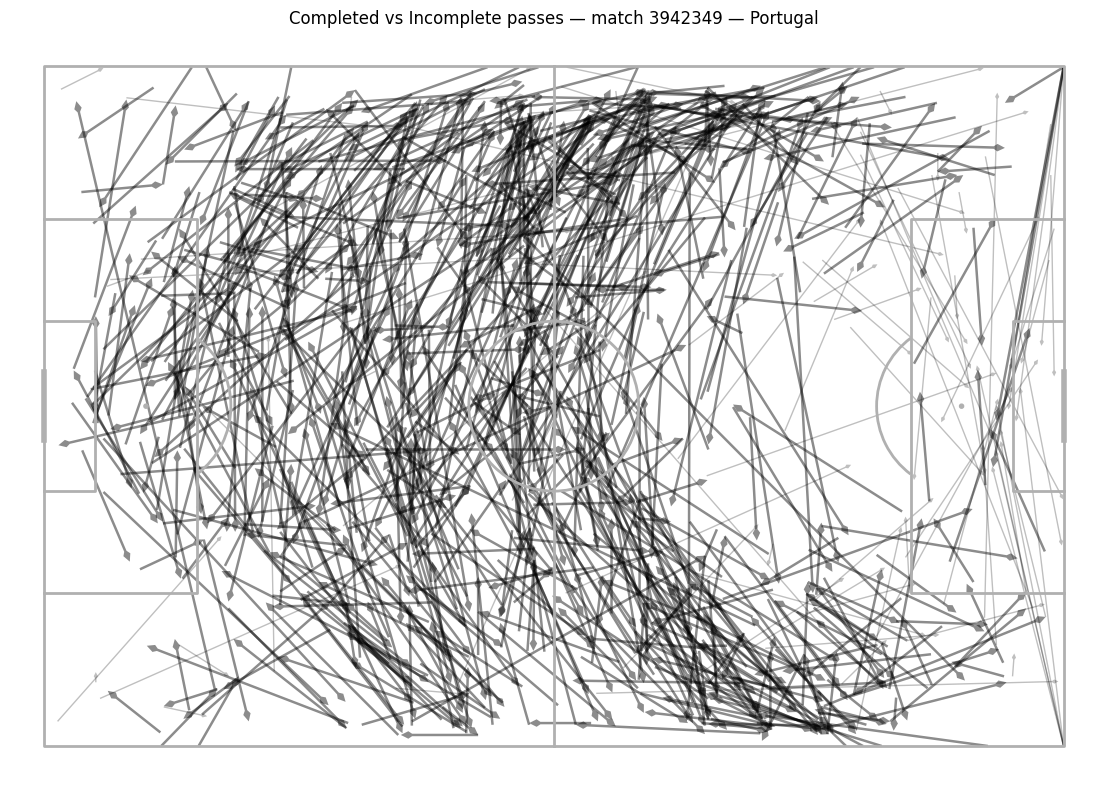

In [16]:
pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

completed = p_team[p_team["is_completed"]]
incomplete = p_team[~p_team["is_completed"]]

# completados
pitch.arrows(
    completed["x"], completed["y"],
    completed["end_x"], completed["end_y"],
    ax=ax,
    width=1.8,
    headwidth=3,
    headlength=3,
    alpha=0.45,
)

# no completados (más finos y más transparentes)
pitch.arrows(
    incomplete["x"], incomplete["y"],
    incomplete["end_x"], incomplete["end_y"],
    ax=ax,
    width=1.0,
    headwidth=3,
    headlength=3,
    alpha=0.25,
)

ax.set_title(f"Completed vs Incomplete passes — match {match_id} — {team_name}")
plt.show()


8) Mapa de pases de un jugador

In [17]:
p_team["player"].value_counts().head(10)


player
Kléper Laveran Lima Ferreira                137
Rúben Santos Gato Alves Dias                107
Nuno Mendes                                 107
Vitor Machado Ferreira                      107
Bernardo Mota Veiga de Carvalho e Silva      83
João Maria Lobo Alves Palhinha Gonçalves     68
Bruno Miguel Borges Fernandes                58
João Pedro Cavaco Cancelo                    48
Rúben Diogo Da Silva Neves                   42
Diogo Meireles Costa                         38
Name: count, dtype: int64

In [18]:
player_name = p_team["player"].value_counts().index[0]
player_name


'Kléper Laveran Lima Ferreira'

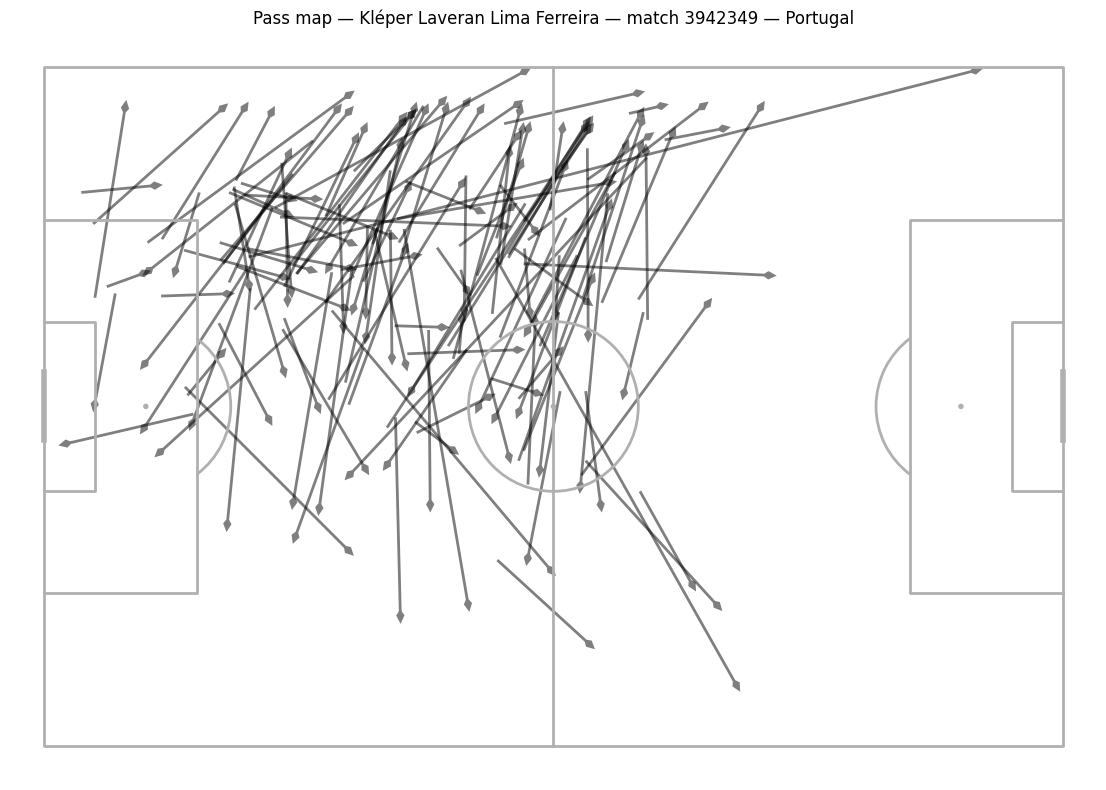

In [19]:
p_player = p_team[p_team["player"] == player_name].copy()

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    p_player["x"], p_player["y"],
    p_player["end_x"], p_player["end_y"],
    ax=ax,
    width=2,
    headwidth=3,
    headlength=3,
    alpha=0.5,
)

ax.set_title(f"Pass map — {player_name} — match {match_id} — {team_name}")
plt.show()


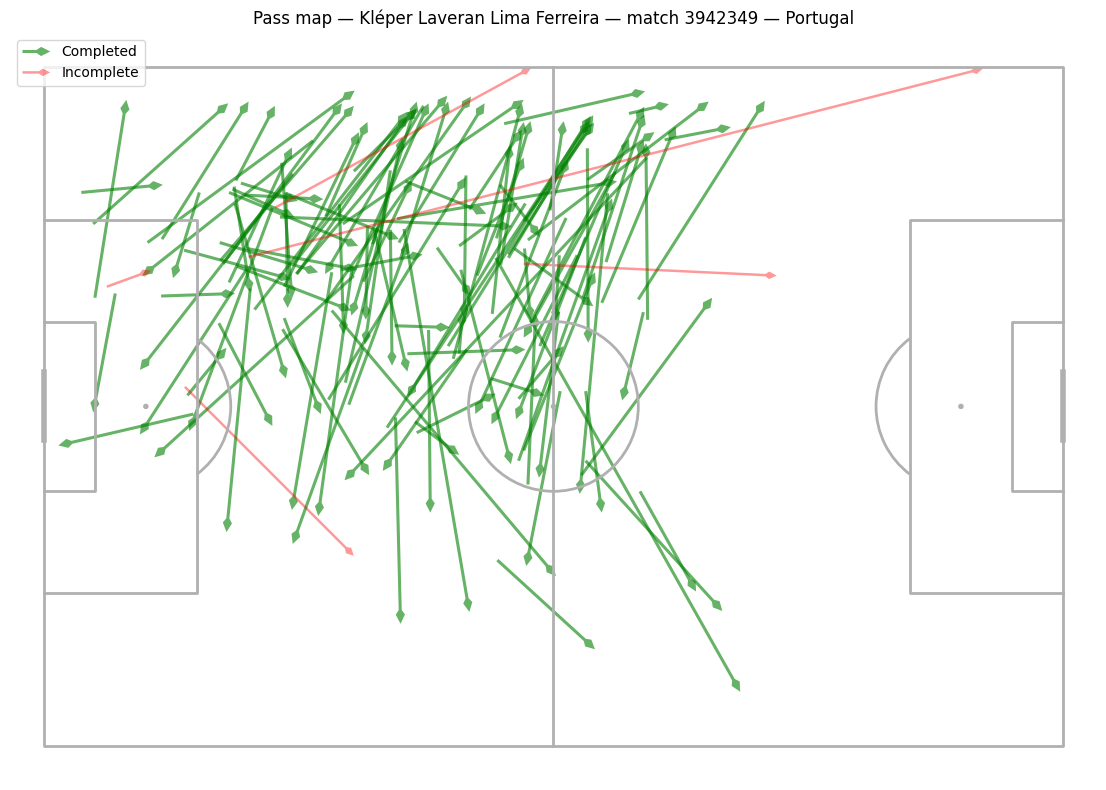

In [20]:
# filtrar pases del jugador
p_player = p_team[p_team["player"] == player_name].copy()

completed = p_player[p_player["is_completed"]]
incomplete = p_player[~p_player["is_completed"]]

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

# pases completados (verde)
pitch.arrows(
    completed["x"], completed["y"],
    completed["end_x"], completed["end_y"],
    ax=ax,
    width=2.2,
    headwidth=3,
    headlength=3,
    color="green",
    alpha=0.6,
    label="Completed"
)

# pases fallados (rojo)
pitch.arrows(
    incomplete["x"], incomplete["y"],
    incomplete["end_x"], incomplete["end_y"],
    ax=ax,
    width=1.8,
    headwidth=3,
    headlength=3,
    color="red",
    alpha=0.4,
    label="Incomplete"
)

ax.set_title(f"Pass map — {player_name} — match {match_id} — {team_name}")
ax.legend(loc="upper left")

plt.show()


In [21]:
# si tu dataset tiene pass_length (lo tiene tu script)
p_team["pass_length"].describe()


count    927.000000
mean      18.887307
std       11.289974
min        1.200000
25%       11.017023
50%       16.324827
75%       23.210234
max       89.303360
Name: pass_length, dtype: float64

9) Filtrado de pases: Pases largos

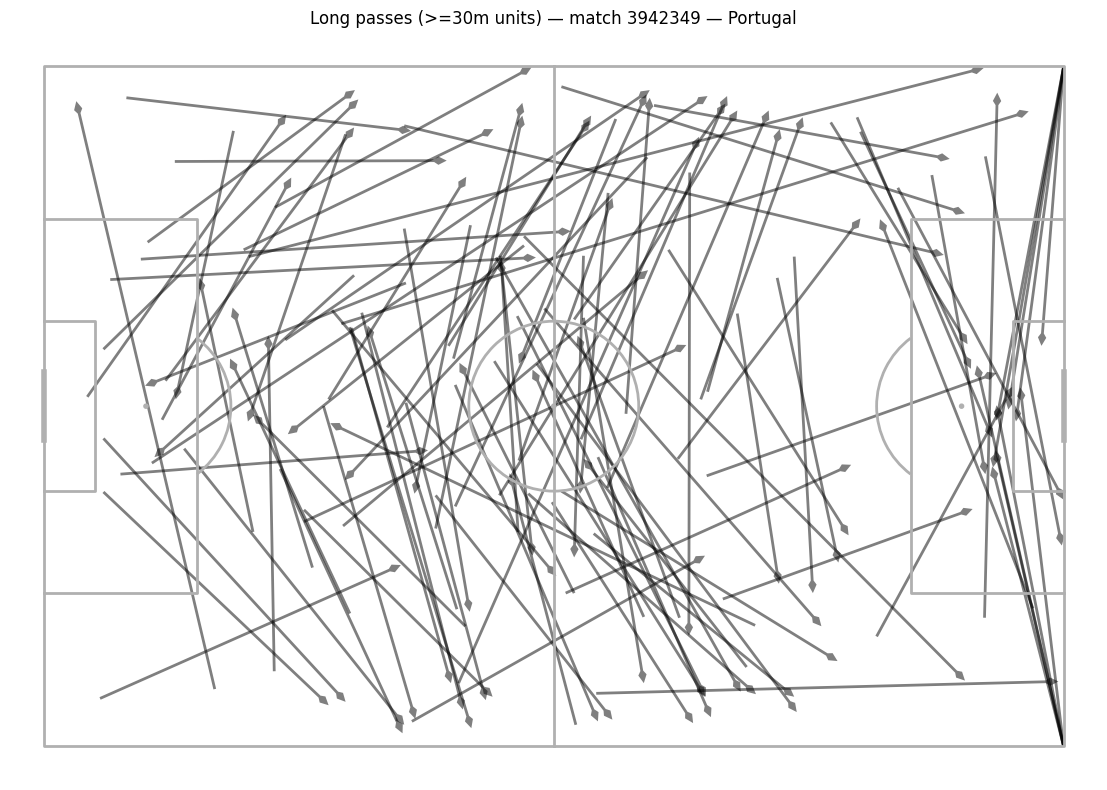

In [22]:
long_passes = p_team[p_team["pass_length"] >= 30]

pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
fig, ax = pitch.draw(figsize=(12, 8))

pitch.arrows(
    long_passes["x"], long_passes["y"],
    long_passes["end_x"], long_passes["end_y"],
    ax=ax,
    width=2,
    headwidth=3,
    headlength=3,
    alpha=0.5,
)

ax.set_title(f"Long passes (>=30m units) — match {match_id} — {team_name}")
plt.show()


10) Outcomes de pase de Florian Wirtz

Partidos disponibles para Florian Wirtz:

 match_id   home_team away_team  passes
  3930168     Germany   Hungary      55
  3930176 Switzerland   Germany      52
  3942226       Spain   Germany      45
  3930158     Germany  Scotland      32
  3940983     Germany   Denmark       5

Graficando match_id=3930168 | Germany (local) vs Hungary (visitante)

              count
pass_outcome       
Completed        51
Incomplete        3
Out               1


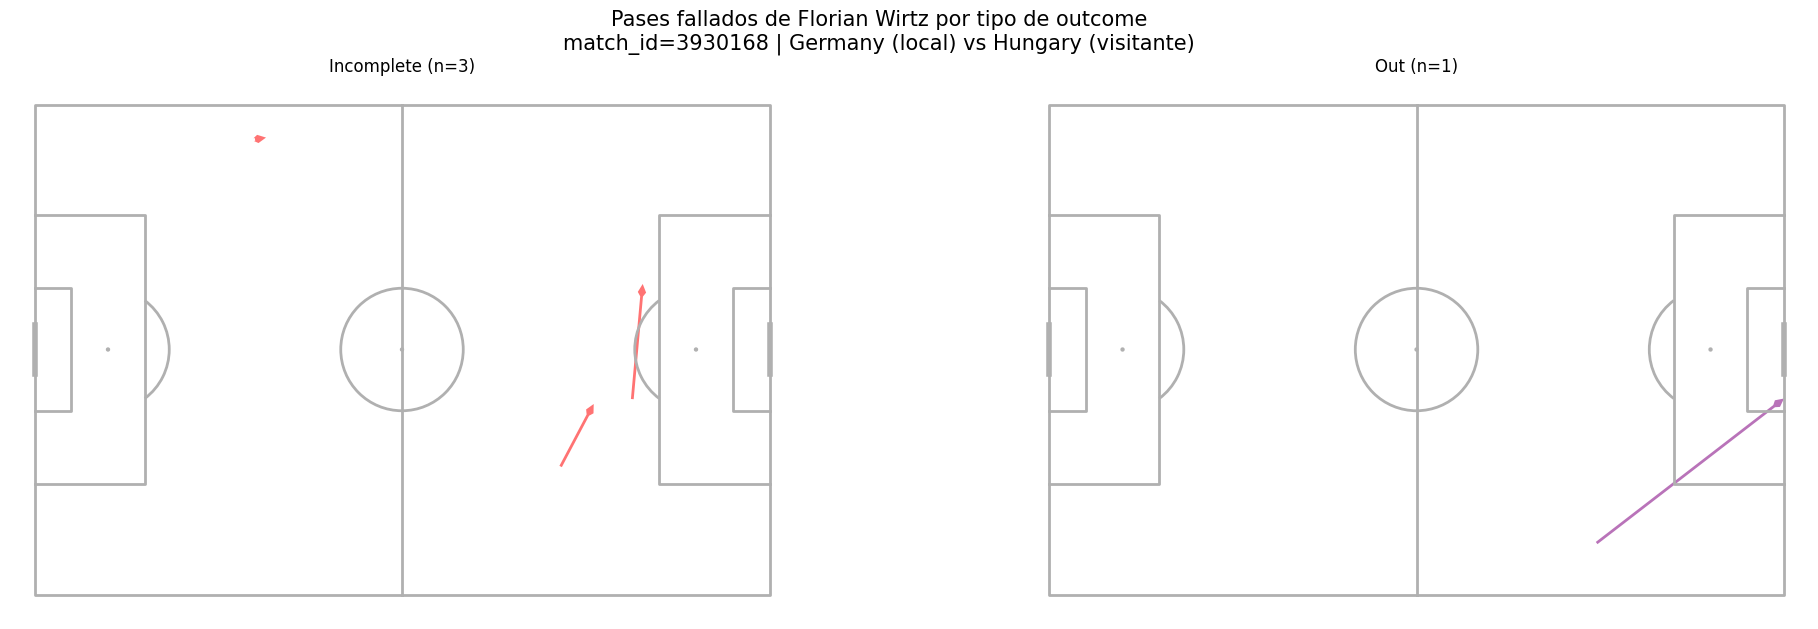

In [30]:
from pathlib import Path
import json
import math

import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch

candidate_roots = [Path.cwd(), Path.cwd().parent]

if "df" not in globals():
    DATA_PATH = next(
        (
            root / "data" / "processed" / "events.parquet"
            for root in candidate_roots
            if (root / "data" / "processed" / "events.parquet").exists()
        ),
        None,
    )
    assert DATA_PATH is not None, "No encuentro data/processed/events.parquet"
    df = pd.read_parquet(DATA_PATH)

if "passes" not in globals():
    passes = df[df["type"] == "Pass"].copy()
    passes["is_completed"] = passes["pass_outcome"].isna()

MATCHES_PATH = next(
    (
        root / "data" / "raw" / "statsbomb" / "euro_2024" / "matches.json"
        for root in candidate_roots
        if (root / "data" / "raw" / "statsbomb" / "euro_2024" / "matches.json").exists()
    ),
    None,
)
assert MATCHES_PATH is not None, "No encuentro data/raw/statsbomb/euro_2024/matches.json"

matches_raw = json.loads(MATCHES_PATH.read_text(encoding="utf-8"))
match_meta = {
    row["match_id"]: {
        "home_team": row["home_team"]["home_team_name"],
        "away_team": row["away_team"]["away_team_name"],
    }
    for row in matches_raw
}

wirtz_name = "Florian Wirtz"
wirtz_passes = passes[passes["player"] == wirtz_name].copy()

if wirtz_passes.empty:
    raise ValueError(f"No hay pases de {wirtz_name} en el dataset.")

available_matches = (
    wirtz_passes.groupby("match_id").size().sort_values(ascending=False).rename("passes").reset_index()
)
available_matches["home_team"] = available_matches["match_id"].map(lambda x: match_meta.get(int(x), {}).get("home_team", "?"))
available_matches["away_team"] = available_matches["match_id"].map(lambda x: match_meta.get(int(x), {}).get("away_team", "?"))

print(f"Partidos disponibles para {wirtz_name}:\n")
print(available_matches[["match_id", "home_team", "away_team", "passes"]].to_string(index=False))

if "wirtz_match_id" not in globals():
    wirtz_match_id = int(available_matches.iloc[0]["match_id"])

selected_meta = match_meta.get(int(wirtz_match_id), {})
home_team = selected_meta.get("home_team", "Home")
away_team = selected_meta.get("away_team", "Away")

wirtz_match_passes = wirtz_passes[wirtz_passes["match_id"] == int(wirtz_match_id)].copy()
if wirtz_match_passes.empty:
    raise ValueError(f"No hay pases de {wirtz_name} en match_id={wirtz_match_id}.")

wirtz_match_passes["outcome_label"] = wirtz_match_passes["pass_outcome"].fillna("Completed")
outcome_counts = wirtz_match_passes["outcome_label"].value_counts().rename_axis("pass_outcome").to_frame("count")

print(f"\nGraficando match_id={wirtz_match_id} | {home_team} (local) vs {away_team} (visitante)\n")
print(outcome_counts.to_string())

failed = wirtz_match_passes[wirtz_match_passes["pass_outcome"].notna()].copy()

if failed.empty:
    print(f"\nNo hay pases fallados de {wirtz_name} en este partido.")
else:
    outcome_order = failed["pass_outcome"].value_counts().index.tolist()
    colors = {
        "Incomplete": "red",
        "Pass Offside": "orange",
        "Out": "purple",
        "Unknown": "gray",
    }

    ncols = min(2, len(outcome_order))
    nrows = math.ceil(len(outcome_order) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(12 * ncols, 7 * nrows))
    axes = axes.ravel() if hasattr(axes, "ravel") else [axes]

    for ax, outcome in zip(axes, outcome_order):
        outcome_df = failed[failed["pass_outcome"] == outcome]
        pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
        pitch.draw(ax=ax)
        pitch.arrows(
            outcome_df["x"], outcome_df["y"],
            outcome_df["end_x"], outcome_df["end_y"],
            ax=ax,
            width=2,
            headwidth=3,
            headlength=3,
            color=colors.get(outcome, "tab:blue"),
            alpha=0.55,
        )
        ax.set_title(f"{outcome} (n={len(outcome_df)})")

    for ax in axes[len(outcome_order):]:
        ax.axis("off")

    fig.suptitle(
        f"Pases fallados de {wirtz_name} por tipo de outcome\nmatch_id={wirtz_match_id} | {home_team} (local) vs {away_team} (visitante)",
        fontsize=15,
    )
    plt.show()
